# Spectral light-curve pipeline (reusable for different targets)

Builds an **emission-line** light curve and a **5100 Å continuum** light curve from a
set of AGN-only, rest-frame spectra. Point it at a new target by editing the
**Configuration** cell only (paths + window variables).

The cells below follow the requested order:

1. **Mean & RMS spectra** from the `*_combined.txt` spectra; define the line / continuum / 5100 Å **windows**.
2. **Linear continuum subtraction** under the line window to isolate the line flux.
3. **Integrate** the line flux (Simpson) and take the **median** 5100 Å flux.
4. Repeat 2–3 on the individual **per-night exposures** to get the same-night **scatter**.
5. **Sum all errors in quadrature** (spectral ⊕ per-night scatter ⊕ [OIII] flux-scaling `syserr`).
6. **Save** the line and 5100 Å light curves.

> **Scope:** this pipeline produces the **WIRO-only** light curves. The
> rapid-variability error floor (median-filter of the light curve) is **not**
> applied here — it belongs on the **combined multi-survey** light curve once the
> other surveys are merged in. It now lives in `median_filter_floor.py`.

Input spectra are expected as 3 columns: `wavelength (Å)  flux  flux_err`.

## Configuration — edit this block for a new target

`INPUT_DIR` must contain the AGN-only, **rest-frame** spectra: both the per-epoch
combined spectra (`*_combined.txt`) and the individual per-night exposures
(`*fits.cali.txt`). `FLUX_LST` supplies the Julian Date of each epoch.

In [1]:
import os
import ast
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson
from scipy.stats import linregress

# =====================================================================
# CONFIGURATION  --  edit this block for a new target / emission line
# =====================================================================

TARGET    = "NGC3227"          # used for plot titles only
LINE_NAME = "hbeta"            # label for the line light curve + output file name

# Directory of AGN-only, REST-FRAME spectra. Must hold BOTH the per-epoch
# combined spectra and the individual per-night exposures.
# Each file: 3 columns -> wavelength (A), flux, flux_err.
INPUT_DIR = "/Users/kaiwenzhang/Desktop/NGC 3227/Halpha_analysis/agn_only_dered_spectra"

# Directory holding the per-night exposures (defaults to INPUT_DIR).
EXPOSURE_DIR = INPUT_DIR

# Epoch list + Julian Dates. First whitespace column = combined-spectrum
# filename, second column = JD. A header line is tolerated (it is skipped).
FLUX_LST = "/Users/kaiwenzhang/Desktop/NGC 3227/NGC3227/flux.lst"

# Directory holding the RAW combined spectra whose header line
#   '#  jd: ... syserr: [...]'  and  '#  combined spec: [...]'
# lists the [OIII]-scaling residuals and the exact exposures that were stacked
# into each combined spectrum. Step 4 measures the per-night scatter ONLY on
# those exposures; read_syserr reads the [OIII] flux-scaling systematic.
# Defaults to the folder containing flux.lst.
RAW_COMBINED_DIR = os.path.dirname(FLUX_LST)

# Where the light curves are written.
OUTPUT_DIR = os.getcwd()

# ---- File-name conventions -------------------------------------------------
COMBINED_PATTERN = "_combined.txt"   # marks a per-epoch combined spectrum
EXPOSURE_PATTERN = "fits.cali.txt"   # marks an individual per-night exposure
# Skip any spectrum whose filename contains one of these substrings.
EXCLUDE_SUBSTR = ["rebin", ".out", "20200205"]   # 20200205 = bad night (NGC3227)

# ---- Spectral windows (rest-frame, Angstrom)  ==  THE WINDOWS VARIABLES =====
# Defaults below are NGC 3227 H-beta. Change these for a different line/target.
LINE_WINDOW = (4800.0, 4929.0)   # emission line to integrate
CONT_BLUE   = (4750.0, 4790.0)   # blue continuum anchor (median flux taken here)
CONT_RED    = (5075.0, 5125.0)   # red  continuum anchor (median flux taken here)
WIN_5100    = (5075.0, 5125.0)   # window whose median flux defines the "5100 A" point

plt.rcParams.update({"figure.dpi": 110, "font.size": 12})
print(f"Target: {TARGET} | line: {LINE_NAME}")
print(f"Input : {INPUT_DIR}")
print(f"Output: {OUTPUT_DIR}")

Target: NGC3227 | line: hbeta
Input : /Users/kaiwenzhang/Desktop/NGC 3227/Halpha_analysis/agn_only_dered_spectra
Output: /Users/kaiwenzhang/PycharmProjects/NGC3227


### Helpers: spectrum loader and epoch list

In [2]:
def load_spectrum(path):
    """Return (wavelength, flux, err) sorted by wavelength.

    Robust to either (N, 3) column layout or (3, N) row layout.
    """
    arr = np.loadtxt(path)
    if arr.ndim != 2:
        raise ValueError(f"Spectrum {path} is not 2-D (shape {arr.shape}).")
    if arr.shape[1] == 3:        # (N, 3): columns are wl, flux, err
        lam, flux, err = arr.T
    elif arr.shape[0] == 3:      # (3, N): rows are wl, flux, err
        lam, flux, err = arr
    else:
        raise ValueError(f"Spectrum {path} is not 3-column (shape {arr.shape}).")
    order = np.argsort(lam)
    return lam[order], flux[order], err[order]


def _excluded(name):
    return any(s in name for s in EXCLUDE_SUBSTR)


def read_used_exposures(combined_name):
    """List the raw exposures that were stacked into a combined spectrum.

    Parses the '#  combined spec: [...]' header line of the raw combined file
    in RAW_COMBINED_DIR. Returns the list of exposure filenames, or None if the
    file / header is unavailable.
    """
    path = os.path.join(RAW_COMBINED_DIR, combined_name)
    if not os.path.exists(path):
        return None
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):      # header sits above the data rows
                break
            if "combined spec:" in line:
                payload = line.split("combined spec:", 1)[1].strip()
                try:
                    return list(ast.literal_eval(payload))
                except (ValueError, SyntaxError):
                    return None
    return None


def read_epochs(flux_lst):
    """Read (name, jd) for the combined epochs, sorted by JD.

    Only keeps rows whose filename contains COMBINED_PATTERN, is not excluded,
    and whose combined spectrum actually exists in INPUT_DIR.
    """
    names, jds = [], []
    with open(flux_lst) as f:
        for line in f:
            parts = line.split()
            if len(parts) < 2:
                continue
            name = parts[0]
            if COMBINED_PATTERN not in name or _excluded(name):
                continue
            try:
                jd = float(parts[1])
            except ValueError:        # header / non-numeric line
                continue
            if not os.path.exists(os.path.join(INPUT_DIR, name)):
                print(f"  [skip] {name}: not found in INPUT_DIR")
                continue
            names.append(name)
            jds.append(jd)
    order = np.argsort(jds)
    names = [names[i] for i in order]
    jds = np.asarray([jds[i] for i in order], dtype=float)
    return names, jds


epoch_names, jd = read_epochs(FLUX_LST)
print(f"{len(epoch_names)} epochs | JD {jd.min():.2f} -> {jd.max():.2f}")

73 epochs | JD 2458803.01 -> 2458999.73


In [3]:
def read_syserr(combined_name):
    """Fractional systematic error of a combined epoch, parsed from its raw
    header line in RAW_COMBINED_DIR:

        #  jd: <jd>  syserr: [v1 v2 v3 ...]

    The bracket lists the per-exposure fractional residuals about the stack mean.
    Mirrors `readspec` in code_lc.py:

        syserr = std(values, ddof=1) / sqrt(N)        # standard error of the mean

    i.e. the uncertainty on the epoch's *mean* flux scale (not the spread of one
    exposure), so it shrinks as more exposures are stacked. Returns 0.0 when the
    header/values are missing or there is only one exposure (N<2 -> no scatter).
    """
    path = os.path.join(RAW_COMBINED_DIR, combined_name)
    if not os.path.exists(path):
        return 0.0
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):       # header sits above the data rows
                break
            if "syserr:" in line:
                try:
                    payload = line.split("syserr:", 1)[1]
                    vals = [float(x) for x in
                            payload.split("[", 1)[1].split("]", 1)[0].split()]
                except (IndexError, ValueError):
                    return 0.0
                if len(vals) > 1:
                    return np.std(vals, ddof=1) / np.sqrt(len(vals))
                return 0.0
    return 0.0


# Fractional systematic error per epoch (aligned with epoch_names / jd).
syserr = np.array([read_syserr(name) for name in epoch_names])
print(f"syserr parsed: {np.count_nonzero(syserr > 0)}/{len(syserr)} epochs nonzero")
print(f"  example {epoch_names[0]} -> {syserr[0]:.4e}")
print(f"  median (nonzero) syserr = {np.median(syserr[syserr > 0]):.4e}  (fractional)")

syserr parsed: 70/73 epochs nonzero
  example 20191114_combined.txt -> 7.6691e-04
  median (nonzero) syserr = 3.0619e-03  (fractional)


## Step 1 — Mean & RMS spectra + define the windows

Stack all combined spectra, compute the pixel-wise mean and RMS, and overlay the
configured windows so you can confirm/adjust them visually before measuring.

In [ ]:
wl = None
fluxes, errs = [], []
for name in epoch_names:
    lam, flux, err = load_spectrum(os.path.join(INPUT_DIR, name))
    if wl is None:
        wl = lam
    elif len(lam) != len(wl) or not np.allclose(lam, wl):
        raise ValueError(f"{name} is on a different wavelength grid; "
                         "resample the spectra onto a common grid first.")
    fluxes.append(flux)
    errs.append(err)

fluxes = np.array(fluxes)
errs = np.array(errs)
mean_flux = fluxes.mean(axis=0)
# propagated error of the pixel-wise mean: sqrt(sum err_i^2) / N
mean_err = np.sqrt(np.sum(errs ** 2, axis=0)) / errs.shape[0]
rms_flux = fluxes.std(axis=0)          # population std (ddof=0) across epochs
# error of the std itself: rms / sqrt(2(N-1))  (Gaussian approximation)
rms_err = rms_flux / np.sqrt(2.0 * (fluxes.shape[0] - 1))
print(f"Stacked {fluxes.shape[0]} spectra x {fluxes.shape[1]} pixels")
print(f"median S/N of mean spectrum: {np.median(mean_flux / mean_err):.1f}")

# Save both as 3-column spectra (wavelength, flux, err) so load_spectrum
# can read them back (e.g. for line-width / BH-mass measurements).
mean_out = os.path.join(OUTPUT_DIR, f"spec_mean_{LINE_NAME}.txt")
rms_out = os.path.join(OUTPUT_DIR, f"spec_rms_{LINE_NAME}.txt")
np.savetxt(mean_out, np.vstack((wl, mean_flux, mean_err)).T)
np.savetxt(rms_out, np.vstack((wl, rms_flux, rms_err)).T)
print("wrote", mean_out)
print("wrote", rms_out)

In [ ]:
def shade_windows(ax):
    ax.axvspan(*LINE_WINDOW, color="orange", alpha=0.35, label="line window")
    ax.axvspan(*CONT_BLUE, color="grey", alpha=0.35, label="continuum anchors")
    ax.axvspan(*CONT_RED, color="grey", alpha=0.35)
    if tuple(WIN_5100) != tuple(CONT_RED):
        ax.axvspan(*WIN_5100, color="green", alpha=0.20, label="5100 window")


lo = min(CONT_BLUE[0], LINE_WINDOW[0]) - 60
hi = max(CONT_RED[1], WIN_5100[1], LINE_WINDOW[1]) + 60
zoom = (wl >= lo) & (wl <= hi)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (spec, title) in zip(axes, [(mean_flux, "mean"), (rms_flux, "rms")]):
    ax.plot(wl, spec, c="k", lw=1)
    shade_windows(ax)
    ax.set_xlim(lo, hi)
    ax.set_ylim(0, np.nanmax(spec[zoom]) * 1.1)
    ax.set_xlabel(r"Rest-frame wavelength ($\AA$)")
    ax.set_title(f"{TARGET}  —  {title} spectrum")
axes[0].fill_between(wl, mean_flux - mean_err, mean_flux + mean_err,
                     color="tab:blue", alpha=0.4, label=r"$\pm 1\sigma$ (propagated)")
axes[0].set_ylabel(r"$f_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
axes[0].legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "spec_mean_rms.pdf"))
plt.show()

## Step 2 — Linear continuum subtraction

Fit a straight line through the mean flux of the blue and red anchor windows
(anchored at each window's center) and subtract it under the line window. What
remains is the isolated emission-line flux.

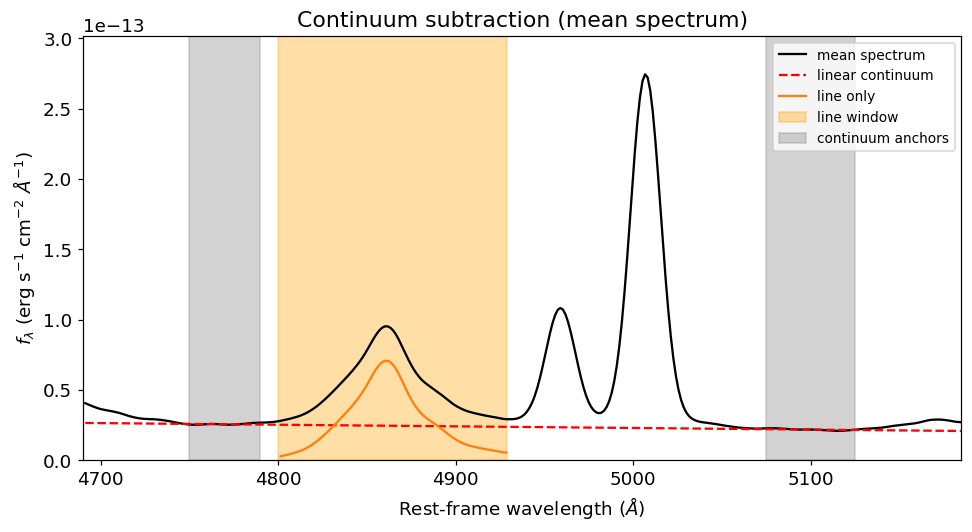

In [6]:
def subtract_local_continuum(lam, flux):
    """Linear pseudo-continuum from the blue & red anchors, subtracted under
    LINE_WINDOW. Returns (line_only, continuum_model).

    Anchor levels use the MEDIAN of each window (robust against cosmic rays /
    bad pixels), matching code_lc.py's mediancl / mediancr."""
    x_blue = 0.5 * (CONT_BLUE[0] + CONT_BLUE[1])
    x_red = 0.5 * (CONT_RED[0] + CONT_RED[1])
    f_blue = np.median(flux[(lam >= CONT_BLUE[0]) & (lam <= CONT_BLUE[1])])
    f_red = np.median(flux[(lam >= CONT_RED[0]) & (lam <= CONT_RED[1])])
    slope, intercept, *_ = linregress([x_blue, x_red], [f_blue, f_red])
    continuum = slope * lam + intercept

    line_only = np.zeros_like(flux)
    m = (lam >= LINE_WINDOW[0]) & (lam <= LINE_WINDOW[1])
    line_only[m] = flux[m] - continuum[m]
    return line_only, continuum


# Demo on the mean spectrum
mean_line, mean_cont = subtract_local_continuum(wl, mean_flux)
m_line = (wl >= LINE_WINDOW[0]) & (wl <= LINE_WINDOW[1])

plt.figure(figsize=(9, 5))
plt.plot(wl[zoom], mean_flux[zoom], c="k", label="mean spectrum")
plt.plot(wl[zoom], mean_cont[zoom], "r--", label="linear continuum")
plt.plot(wl[m_line], mean_line[m_line], c="tab:orange", label="line only")
shade_windows(plt.gca())
plt.xlim(lo, hi)
plt.ylim(0, np.nanmax(mean_flux[zoom]) * 1.1)
plt.xlabel(r"Rest-frame wavelength ($\AA$)")
plt.ylabel(r"$f_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
plt.legend(fontsize=9)
plt.title("Continuum subtraction (mean spectrum)")
plt.tight_layout()
plt.show()

## Step 3 — Integrate the line, average the 5100 Å flux

For every epoch (combined spectrum): Simpson-integrate the continuum-subtracted
line over the line window, and take the mean flux in the 5100 Å window.

Spectral errors follow `code_lc.py`:

- **Hbeta** : `err = sqrt(Σ err_i²) · dwave` — per-pixel noise propagated through the
  integral, with `dwave` **outside** the square root so the error carries
  integrated-flux units (erg s⁻¹ cm⁻²).
- **5100 Å** : `err = std(flux)/√N` — the **empirical** scatter of the window flux
  (error on the mean level). Captures sky residuals, fringing, weak lines and
  correlated noise that the formal err column misses.

In [7]:
def integrate_line(lam, flux, err):
    """Integrated line flux (continuum subtracted) + propagated error.

    F   = integral of (f - continuum) dlambda over LINE_WINDOW   (Simpson)
    err = sqrt( sum(err_i^2) ) * dwave

    dwave is OUTSIDE the square root so the error keeps integrated-flux units:
    per-pixel err [erg s^-1 cm^-2 A^-1] -> sqrt(sum err^2) [erg s^-1 cm^-2 A^-1]
    -> * dwave [A] -> [erg s^-1 cm^-2]. Matches code_lc.py:
        efhb = np.sum(efagn0**2)**0.5 * (wave0[1] - wave0[0]).
    (Continuum-anchor error is intentionally not propagated: the windows are
    chosen carefully, so that term is negligible.)
    """
    line_only, _ = subtract_local_continuum(lam, flux)
    m = (lam >= LINE_WINDOW[0]) & (lam <= LINE_WINDOW[1])
    lam_m, err_m = lam[m], err[m]
    flux_line = simpson(line_only[m], lam_m)
    dwave = lam_m[1] - lam_m[0]
    err_line = np.sqrt(np.sum(err_m ** 2)) * dwave
    return flux_line, err_line


def average_5100(lam, flux, err):
    """MEDIAN flux in the 5100 A window + EMPIRICAL error of the level:

        value = median(flux)                       # robust vs cosmic rays
        err   = std(flux, ddof=1) / sqrt(N)        # empirical window scatter

    The error is the observed scatter of the window pixels divided by sqrt(N),
    NOT the formal err column -- it captures sky-subtraction residuals, fringing,
    weak lines and correlated noise the err column misses. Matches code_lc.py:
        median5100 = np.median(flux); emedian5100 = np.std(flux)/sqrt(N).
    """
    m = (lam >= WIN_5100[0]) & (lam <= WIN_5100[1])
    n = np.count_nonzero(m)
    flux_c = np.median(flux[m])
    err_c = np.std(flux[m], ddof=1) / np.sqrt(n)
    return flux_c, err_c


line_flux, line_err_spec = [], []
c5100_flux, c5100_err_spec = [], []
for name in epoch_names:
    lam, flux, err = load_spectrum(os.path.join(INPUT_DIR, name))
    f_line, e_line = integrate_line(lam, flux, err)
    f_c, e_c = average_5100(lam, flux, err)
    line_flux.append(f_line)
    line_err_spec.append(e_line)
    c5100_flux.append(f_c)
    c5100_err_spec.append(e_c)

line_flux = np.array(line_flux)
line_err_spec = np.array(line_err_spec)
c5100_flux = np.array(c5100_flux)
c5100_err_spec = np.array(c5100_err_spec)
print(f"Measured {len(line_flux)} epochs.")

Measured 73 epochs.


## Step 4 — Per-night scatter from the raw exposures

For each epoch we use **only the exposures that were actually stacked** into the
combined spectrum — read from the `#  combined spec: [...]` header of the raw
combined file (`RAW_COMBINED_DIR`). Extra same-night exposures that were not
stacked are ignored. We run the **same** Steps 2–3 on each used exposure and take
the standard deviation across them. Epochs with <2 used exposures get a scatter of 0.

If a combined file has no such header, we fall back to all same-night
`EXPOSURE_PATTERN` files and print a warning.

In [8]:
all_exposures = [f for f in os.listdir(EXPOSURE_DIR)
                 if EXPOSURE_PATTERN in f and not _excluded(f)]
print(f"{len(all_exposures)} per-night exposure files in EXPOSURE_DIR.")

line_scatter, c5100_scatter, n_used = [], [], []
for name in epoch_names:
    used_raw = read_used_exposures(name)
    used = [ i.split('.')[0] + f'.{EXPOSURE_PATTERN}' for i in used_raw ] # correct to the format used for per night exposures
    if used is None:                                  # no header -> fall back
        used = [f for f in all_exposures if f.startswith(name[:8])]
        print(used)
        print(f"  [warn] {name}: no 'combined spec' header; using all "
              f"{len(used)} same-night exposures.")

    f_lines, f_cs = [], []
    
    for exp in used:
        epath = os.path.join(EXPOSURE_DIR, exp)
        if not os.path.exists(epath):
            print(f"  [warn] {name}: stacked exposure not found in "
                  f"EXPOSURE_DIR: {exp}")
            continue
        lam, flux, err = load_spectrum(epath)
        f_lines.append(integrate_line(lam, flux, err)[0])
        f_cs.append(average_5100(lam, flux, err)[0])

    # sample std (ddof=1): unbiased dispersion estimate for small N
    n_used.append(len(f_lines))
    line_scatter.append(np.nanstd(f_lines, ddof=1)/np.sqrt(len(f_lines)) if len(f_lines) > 1 else 0.0)
    c5100_scatter.append(np.nanstd(f_cs, ddof=1)/np.sqrt(len(f_cs)) if len(f_cs) > 1 else 0.0)

line_scatter = np.array(line_scatter)
c5100_scatter = np.array(c5100_scatter)
n_used = np.array(n_used)
print(f"exposures per epoch: min={n_used.min()} max={n_used.max()} "
      f"median={int(np.median(n_used))}")
print(f"median per-night scatter  line={np.median(line_scatter):.3e}  "
      f"5100={np.median(c5100_scatter):.3e}")

215 per-night exposure files in EXPOSURE_DIR.
exposures per epoch: min=1 max=6 median=3
median per-night scatter  line=3.141e-14  5100=3.098e-16


## Step 5 — Sum all errors in quadrature

`err_total = sqrt(err_spectral² + err_scatter² + err_syserr²)` for each light
curve, where `err_syserr = syserr · flux` is the per-epoch [OIII] flux-scaling
systematic parsed from the combined-spectrum header.

> The rapid-variability (median-filter) floor is **not** applied here — this
> pipeline yields the **WIRO-only** light curves. Apply that floor on the merged
> multi-survey light curve later (see `median_filter_floor.py`).

In [9]:
# Per-epoch [OIII] flux-scaling systematic: fractional syserr (combined-spectrum
# header) times the epoch flux. Mirrors code_lc.py's (syserr*fhb)/(syserr*mediancr).
line_syserr = syserr * line_flux
c5100_syserr = syserr * c5100_flux

line_err = np.sqrt(line_err_spec ** 2 + line_scatter ** 2 + line_syserr ** 2)
c5100_err = np.sqrt(c5100_err_spec ** 2 + c5100_scatter ** 2 + c5100_syserr ** 2)

print("Median fractional error budget:")
print(f"  line : spec {np.median(line_err_spec/line_flux):.3%} | "
      f"scatter {np.median(line_scatter/line_flux):.3%} | "
      f"syserr {np.median(line_syserr/line_flux):.3%} | "
      f"total {np.median(line_err/line_flux):.3%}")
print(f"  5100 : spec {np.median(c5100_err_spec/c5100_flux):.3%} | "
      f"scatter {np.median(c5100_scatter/c5100_flux):.3%} | "
      f"syserr {np.median(c5100_syserr/c5100_flux):.3%} | "
      f"total {np.median(c5100_err/c5100_flux):.3%}")

Median fractional error budget:
  line : spec 0.631% | scatter 0.909% | syserr 0.286% | total 1.208%
  5100 : spec 0.518% | scatter 1.488% | syserr 0.286% | total 1.586%


## Step 6 — Save the light curves

Written as 3 columns: `JD  flux  flux_err` — ready for CCF / MICA.

wrote /Users/kaiwenzhang/PycharmProjects/NGC3227/lc_hbeta.txt
wrote /Users/kaiwenzhang/PycharmProjects/NGC3227/lc_5100.txt


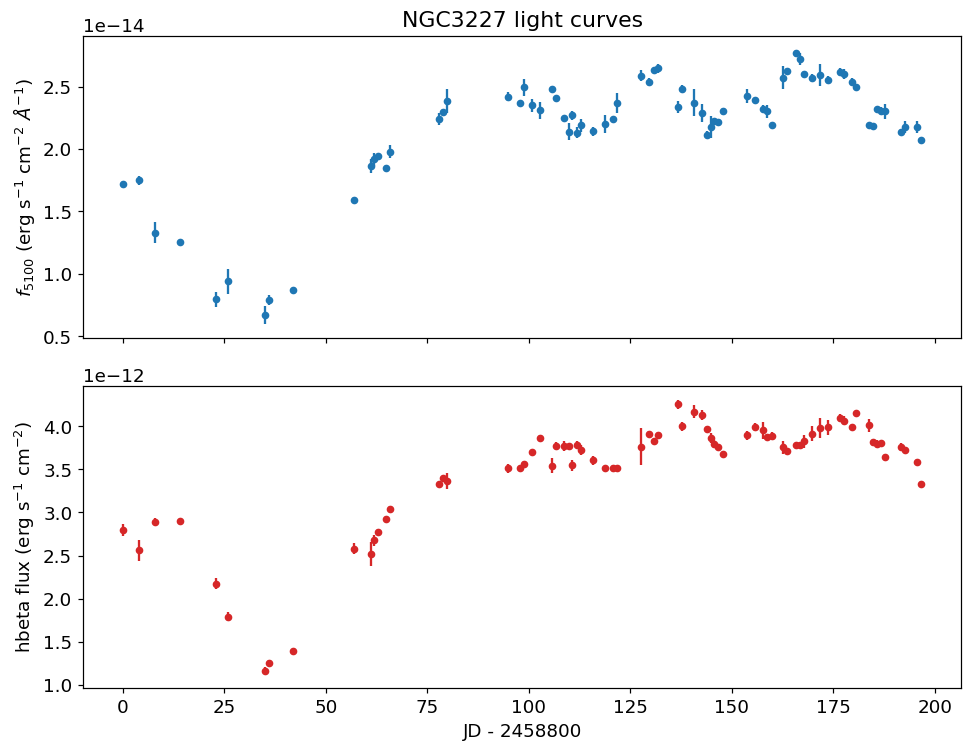

In [10]:
line_out = os.path.join(OUTPUT_DIR, f"lc_{LINE_NAME}.txt")
c5100_out = os.path.join(OUTPUT_DIR, "lc_5100.txt")
np.savetxt(line_out, np.vstack((jd, line_flux, line_err)).T)
np.savetxt(c5100_out, np.vstack((jd, c5100_flux, c5100_err)).T)
print("wrote", line_out)
print("wrote", c5100_out)

t = jd - jd[0]
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].errorbar(t, c5100_flux, c5100_err, fmt="o", ms=4, c="tab:blue")
axes[0].set_ylabel(r"$f_{5100}$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
axes[1].errorbar(t, line_flux, line_err, fmt="o", ms=4, c="tab:red")
axes[1].set_ylabel(f"{LINE_NAME} flux (erg s$^{{-1}}$ cm$^{{-2}}$)")
axes[1].set_xlabel("JD - 2458800")
axes[0].set_title(f"{TARGET} light curves")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"light_curves_{LINE_NAME}.pdf"))
plt.show()